# Structural Phase Transitions in Tensor Geometry

## From resolution degradation to emergent structure

The [resolution degradation model](tensor_resolution.ipynb) showed that control effort
inflates $G_{ik}$, increasing observation noise anisotropically. Here we take the next
step: when $G_{ik}$ dynamics include **nonlinear self-interaction**, the tensor can undergo
**spontaneous symmetry breaking** — organizing into a stable anisotropic configuration.

This organized structure is not merely a passive effect. Through the $G$–state coupling,
the anisotropic tensor **reshapes the system's effective dynamics**, creating directional
channels of enhanced stability. The central question: **can a controller exploit emergent
geometric structure, and what destroys it?**

### Extended model

| Component | Equation | New feature |
|---|---|---|
| State | $\dot{x} = (A + \kappa\,Q)\,x + Bu + w$ | $G$–state coupling via traceless part $Q = G - \tfrac{1}{2}\mathrm{tr}(G)\cdot I$ |
| $G$ dynamics | $\dot{G}_{ik} = \alpha\,\lvert u\rvert^{\gamma-2} u_i u_k - \frac{G_{ik}-\delta_{ik}}{\tau_G} + S_{ik}$ | Landau self-interaction $S$ |
| Self-interaction | $S = \mu\,\bigl(\tfrac{1}{2}\mathrm{tr}(G) - g_c\bigr)\,Q - \nu\,\lVert Q\rVert^2\,Q$ | Phase transition at $\mathrm{tr}(G)/2 = g_c$ |
| Observation | $y = x + (\sigma_0 I + \beta G)\,\eta(t)$ | Unchanged from resolution model |

**Physical picture.** The self-interaction $S$ implements a *Landau-type phase transition*:
- Below the critical scale ($\mathrm{tr}(G)/2 < g_c$): any anisotropy decays, $G$ stays isotropic
- Above the critical scale ($\mathrm{tr}(G)/2 > g_c$): anisotropy is amplified — $G$ spontaneously organizes
- Cubic saturation ($\nu$) prevents blow-up, giving a stable organized state

The $G$–state coupling ($\kappa\, Q\, x$) means the organized tensor modifies the effective plant:
directions of high $G$ gain extra damping ($\kappa < 0$), while low-$G$ directions become less stable.
This creates a **complementary structure**: where observations are noisy, physics provides stability;
where observations are clean, active control is needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cm as mpl_cm

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.3})

# --- Plant (shared with tensor_resolution.ipynb) ---
A  = np.array([[-0.1,  1.0],
               [-2.0, -0.5]])
B  = np.array([[1.0, 0.0],
               [0.0, 0.3]])
w  = np.array([0.5, 0.3])
x0 = np.array([1.0, 0.5])
G0 = np.eye(2)

sigma0 = 0.04
u_max  = 3.0
dt     = 0.01
T      = 60.0

# --- G dynamics (base) ---
alpha = 0.5       # control -> G coupling (increased from 0.3 for clearer transition)
beta  = 0.5       # G -> noise coupling
tau_G = 5.0       # relaxation G -> I
gamma = 1.0       # exponent (1 = scalar-model compatible)

# --- Self-interaction (Landau) ---
mu  = 0.8         # self-interaction strength
g_c = 1.15        # critical half-trace for phase transition
nu  = 0.3         # cubic saturation

# --- G-state coupling ---
kappa = -0.15     # traceless G modifies effective plant (negative = stabilising)

# --- Three regimes ---
BASELINE  = dict(mu=0.0, kappa=0.0)     # no structure
ORGANIZED = dict(mu=0.8, kappa=0.0)     # self-interaction only
FULL      = dict(mu=0.8, kappa=-0.15)   # self-interaction + G-state coupling

REGIMES    = {"Baseline": BASELINE, "Organized": ORGANIZED, "Full": FULL}
REG_COLORS = {"Baseline": "C0", "Organized": "C1", "Full": "C2"}

print(f"Plant eigenvalues: {np.linalg.eigvals(A)}")
print(f"Phase transition: tr(G)/2 > g_c = {g_c}")
print(f"Self-interaction: mu={mu}, g_c={g_c}, nu={nu}")
print(f"G-state coupling: kappa={kappa}")


Plant eigenvalues: [-0.3+1.4j -0.3-1.4j]
Phase transition: tr(G)/2 > g_c = 1.15
Self-interaction: mu=0.8, g_c=1.15, nu=0.3
G-state coupling: kappa=-0.15


In [2]:
def simulate(controller_fn, regime=None, seed=42):
    """Simulate 2D system with G self-interaction and G-state coupling."""
    rng = np.random.default_rng(seed)
    n = int(round(T / dt))
    I2 = np.eye(2)

    r = regime or {}
    a_  = r.get("alpha", alpha)
    b_  = r.get("beta", beta)
    tg  = r.get("tau_G", tau_G)
    gam = r.get("gamma", gamma)
    m_  = r.get("mu", mu)
    gc  = r.get("g_c", g_c)
    nv  = r.get("nu", nu)
    kap = r.get("kappa", kappa)

    t_arr   = np.zeros(n + 1)
    x_arr   = np.zeros((n + 1, 2))
    u_arr   = np.zeros((n + 1, 2))
    G_arr   = np.zeros((n + 1, 2, 2))
    eig_arr = np.zeros((n + 1, 2))

    x = x0.copy()
    G = G0.copy()

    for i in range(n + 1):
        ti = i * dt
        noise_amp = sigma0 * I2 + b_ * G
        y = x + noise_amp @ rng.standard_normal(2)

        eig_arr[i] = np.linalg.eigvalsh(G)
        t_arr[i]   = ti
        x_arr[i]   = x.copy()
        G_arr[i]   = G.copy()

        u = controller_fn(ti, y, G)
        u_arr[i] = u
        if i == n:
            break

        # State: plant + G-state coupling via traceless part Q
        Q = G - 0.5 * np.trace(G) * I2
        dx = (A @ x + kap * Q @ x + B @ u + w) * dt
        x += dx

        # G: control drive + relaxation + Landau self-interaction
        u_norm = np.linalg.norm(u)
        if u_norm > 1e-12:
            drive = a_ * (u_norm ** (gam - 2)) * np.outer(u, u)
        else:
            drive = np.zeros((2, 2))

        Q = G - 0.5 * np.trace(G) * I2
        Q_sq = np.trace(Q @ Q)
        r_val = 0.5 * np.trace(G) - gc
        S = m_ * r_val * Q - nv * Q_sq * Q

        dG = (drive - (G - I2) / tg + S) * dt
        G += dG
        G = 0.5 * (G + G.T)

        ev, evec = np.linalg.eigh(G)
        ev = np.clip(ev, 0.5, 20.0)
        G = evec @ np.diag(ev) @ evec.T

    return {"t": t_arr, "x": x_arr, "u": u_arr, "G": G_arr, "eigvals": eig_arr}


def metrics(res, warmup=25.0):
    idx = res["t"] >= warmup
    x, u, ev = res["x"][idx], res["u"][idx], res["eigvals"][idx]
    return {
        "error":  float(np.mean(np.linalg.norm(x, axis=1))),
        "effort": float(np.mean(np.sum(u**2, axis=1))),
        "aniso":  float(np.mean(ev[:, 1] / np.clip(ev[:, 0], 1e-6, None))),
        "trace":  float(np.mean(ev[:, 0] + ev[:, 1])),
    }


def make_proportional(K):
    def ctrl(t, y, G):
        return np.clip(-K * y, -u_max, u_max)
    return ctrl


def make_aniso_aware(K_base):
    def ctrl(t, y, G):
        ev, evec = np.linalg.eigh(G)
        wt = 1.0 / np.clip(ev, 0.5, None)
        wt /= wt.max()
        K_mat = K_base * evec @ np.diag(wt) @ evec.T
        return np.clip(-K_mat @ y, -u_max, u_max)
    return ctrl


print("Engine ready. Controllers: proportional, aniso-aware.")


Engine ready. Controllers: proportional, aniso-aware.


## 1. Structural phase transition: bifurcation diagram

We sweep proportional gain $K$ and compare three regimes:
- **Baseline** ($\mu{=}0, \kappa{=}0$): standard resolution model, no structure
- **Organized** ($\mu{=}0.8, \kappa{=}0$): self-interaction creates anisotropy, but $G$ doesn't reshape dynamics
- **Full** ($\mu{=}0.8, \kappa{=}{-}0.15$): organized $G$ also reshapes the effective plant

If the self-interaction works, anisotropy should **accelerate** above $g_c$ — the Landau
bifurcation point. The tracking error should show a non-trivial dependence on structure
formation.

Running bifurcation sweep ... 

done.


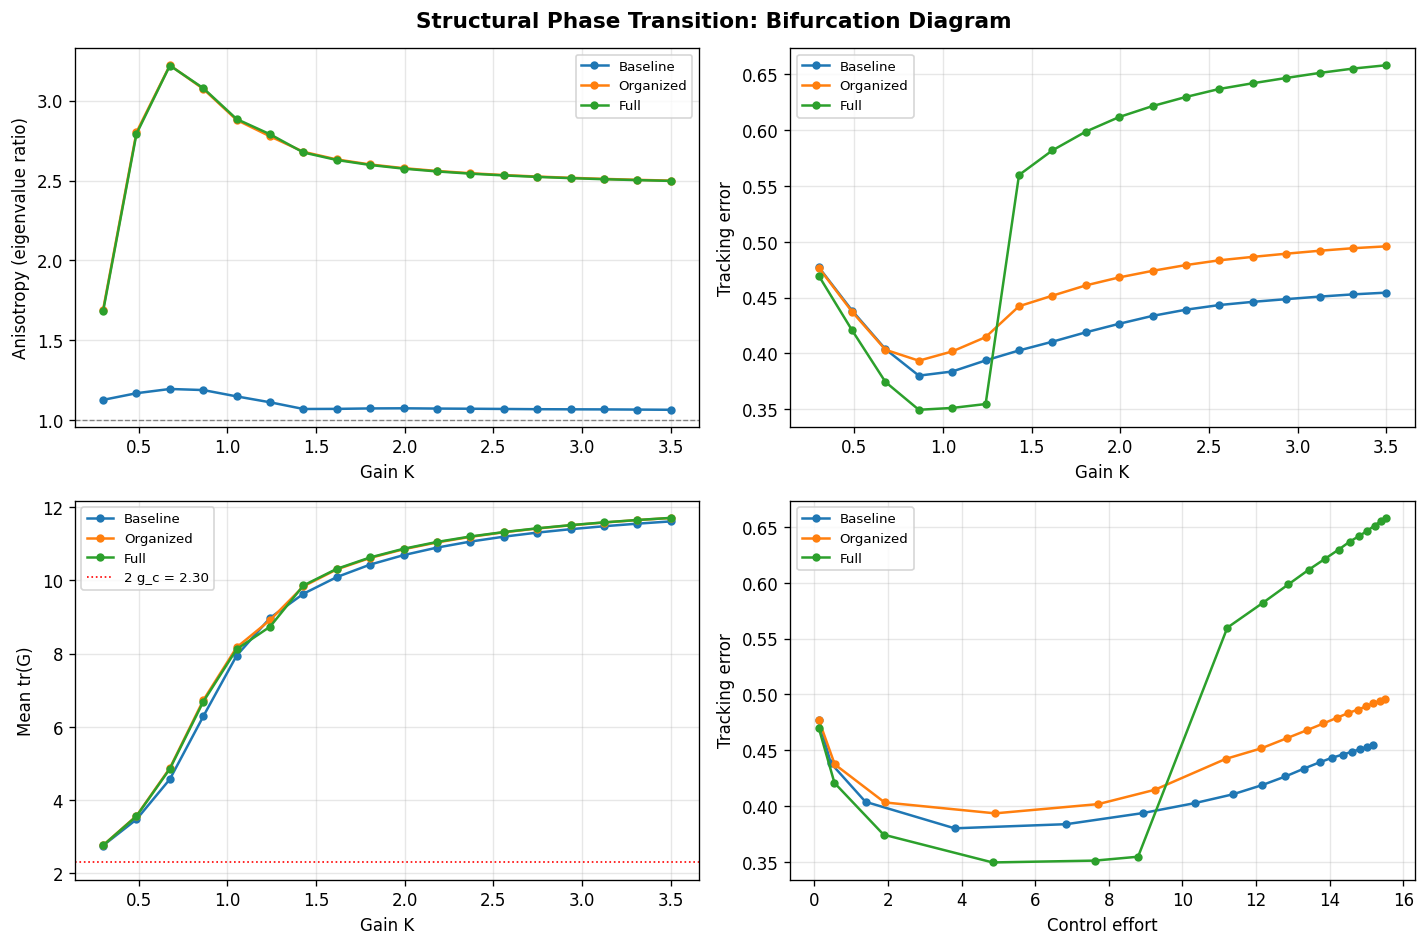

Baseline    : best error=0.3801 at K=0.86, aniso=1.19, tr(G)=6.29
Organized   : best error=0.3935 at K=0.86, aniso=3.07, tr(G)=6.73
Full        : best error=0.3495 at K=0.86, aniso=3.08, tr(G)=6.69


In [3]:
K_vals = np.linspace(0.3, 3.5, 18)

results = {name: {"K": [], "error": [], "aniso": [], "trace": [], "effort": []}
           for name in REGIMES}

print("Running bifurcation sweep ...", end=" ", flush=True)
for K in K_vals:
    ctrl = make_proportional(K)
    for name, reg in REGIMES.items():
        r = simulate(ctrl, regime=reg, seed=42)
        m = metrics(r)
        for key in ["error", "aniso", "trace", "effort"]:
            results[name][key].append(m[key])
        results[name]["K"].append(K)
print("done.")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for name in REGIMES:
    K = results[name]["K"]
    c = REG_COLORS[name]
    axes[0, 0].plot(K, results[name]["aniso"], 'o-', color=c, label=name, ms=4, lw=1.5)
    axes[0, 1].plot(K, results[name]["error"], 'o-', color=c, label=name, ms=4, lw=1.5)
    axes[1, 0].plot(K, results[name]["trace"], 'o-', color=c, label=name, ms=4, lw=1.5)
    axes[1, 1].plot(results[name]["effort"], results[name]["error"],
                    'o-', color=c, label=name, ms=4, lw=1.5)

axes[0, 0].set(xlabel="Gain K", ylabel="Anisotropy (eigenvalue ratio)")
axes[0, 0].axhline(1.0, color='gray', ls='--', lw=0.8)
axes[0, 1].set(xlabel="Gain K", ylabel="Tracking error")
axes[1, 0].set(xlabel="Gain K", ylabel="Mean tr(G)")
axes[1, 0].axhline(2 * g_c, color='red', ls=':', lw=1, label=f"2 g_c = {2*g_c:.2f}")
axes[1, 1].set(xlabel="Control effort", ylabel="Tracking error")

for ax in axes.flat:
    ax.legend(fontsize=8)

fig.suptitle("Structural Phase Transition: Bifurcation Diagram",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for name in REGIMES:
    r = results[name]
    best_i = int(np.argmin(r["error"]))
    print(f"{name:12s}: best error={r['error'][best_i]:.4f} at K={r['K'][best_i]:.2f}, "
          f"aniso={r['aniso'][best_i]:.2f}, tr(G)={r['trace'][best_i]:.2f}")


## 2. Dynamics of structure formation

Running at $K = 2.0$ (above the phase transition threshold), we visualize:
- **Top row**: $G$ eigenvalue time series showing the symmetry-breaking split
- **Bottom row**: State-space trajectory with $G$ ellipses showing how the organized
  tensor creates directional structure

Each column corresponds to one regime.

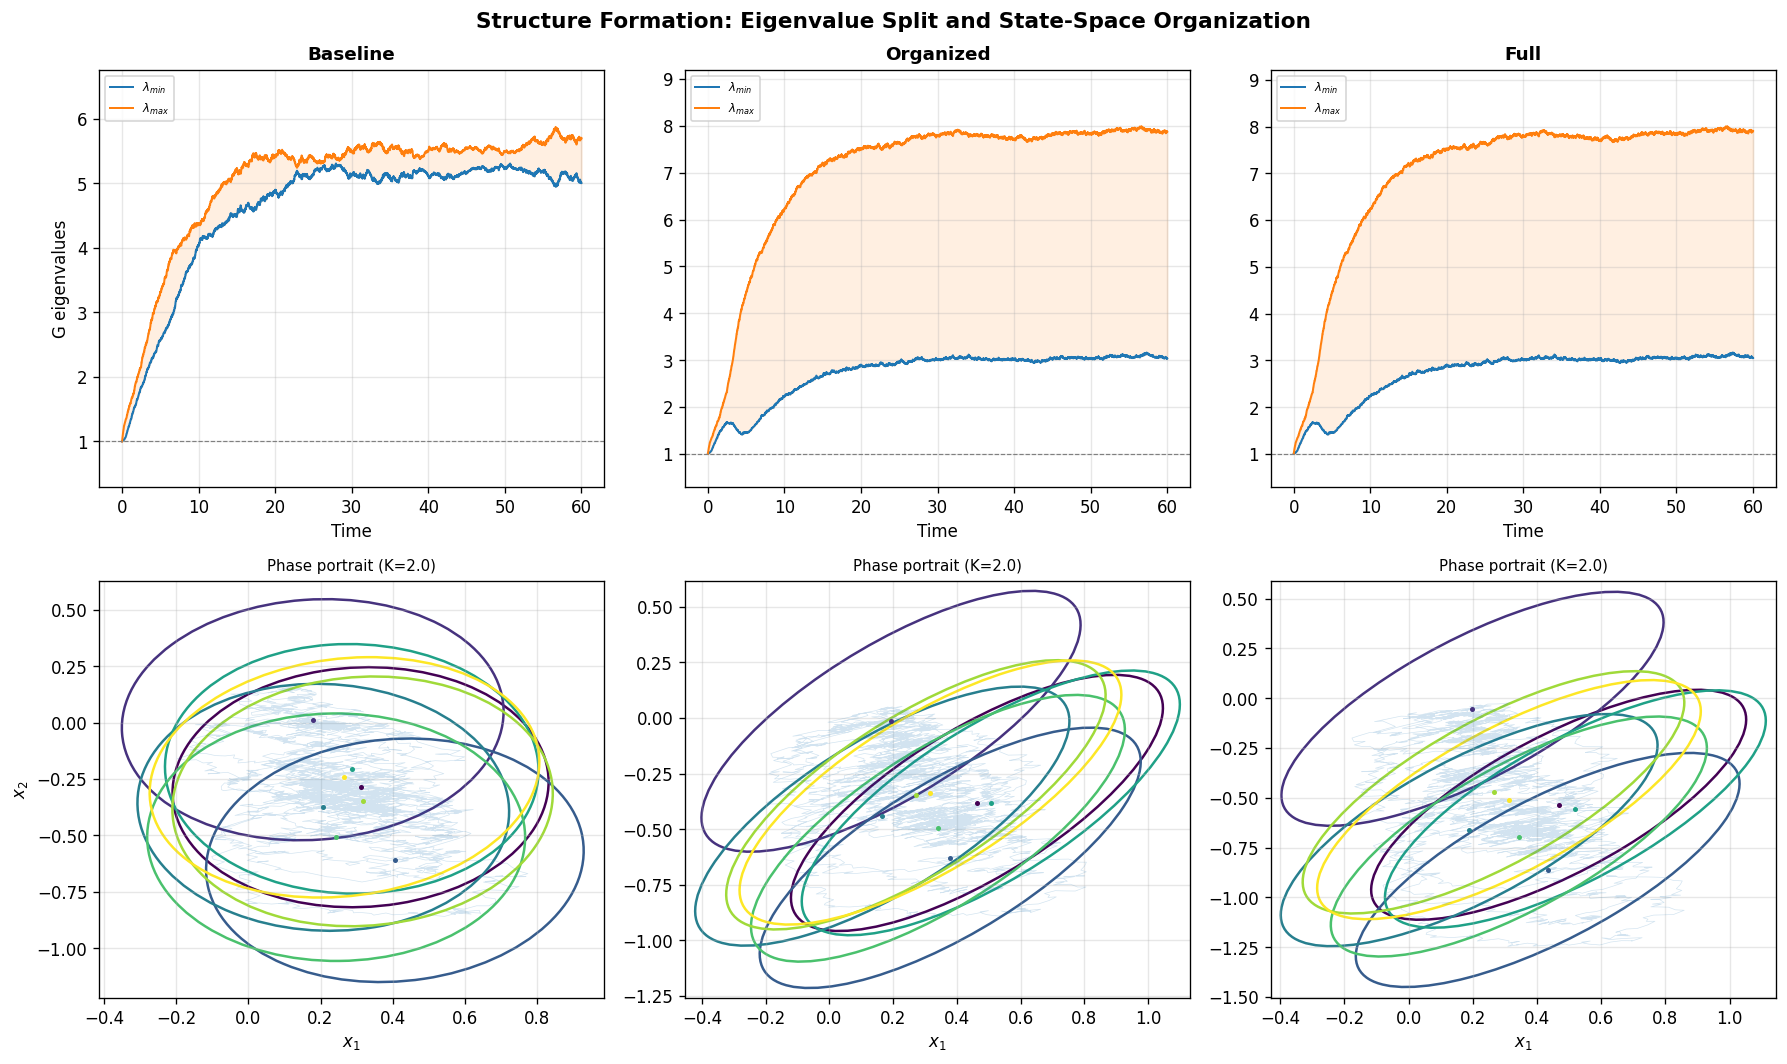

In [4]:
K_demo = 2.0
ctrl = make_proportional(K_demo)
regime_list = [("Baseline", BASELINE), ("Organized", ORGANIZED), ("Full", FULL)]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (name, reg) in enumerate(regime_list):
    r = simulate(ctrl, regime=reg, seed=42)
    t, x, ev, G_all = r["t"], r["x"], r["eigvals"], r["G"]

    # Top: eigenvalue time series
    axes[0, col].plot(t, ev[:, 0], label=r"$\lambda_{min}$", color="C0", lw=1.2)
    axes[0, col].plot(t, ev[:, 1], label=r"$\lambda_{max}$", color="C1", lw=1.2)
    axes[0, col].fill_between(t, ev[:, 0], ev[:, 1], alpha=0.12, color="C1")
    axes[0, col].axhline(1.0, color='gray', ls='--', lw=0.7)
    axes[0, col].set_title(name, fontsize=11, fontweight='bold')
    if col == 0:
        axes[0, col].set_ylabel("G eigenvalues")
    axes[0, col].legend(fontsize=7, loc='upper left')
    axes[0, col].set_ylim(0.3, max(ev[:, 1].max() * 1.15, 2.5))
    axes[0, col].set_xlabel("Time")

    # Bottom: phase portrait with G ellipses
    warm_idx = int(25.0 / dt)
    axes[1, col].plot(x[warm_idx:, 0], x[warm_idx:, 1],
                      '-', color='C0', alpha=0.2, lw=0.4)
    n_ell = 8
    ell_indices = np.linspace(warm_idx, len(t) - 1, n_ell, dtype=int)
    for j, idx in enumerate(ell_indices):
        G_j = G_all[idx]
        ev_j, evec_j = np.linalg.eigh(G_j)
        angle = np.degrees(np.arctan2(evec_j[1, 1], evec_j[0, 1]))
        scale = 0.1
        e = Ellipse(x[idx], width=2*scale*ev_j[1], height=2*scale*ev_j[0],
                    angle=angle, fill=False,
                    edgecolor=mpl_cm.viridis(j / max(n_ell - 1, 1)),
                    linewidth=1.5)
        axes[1, col].add_patch(e)
        axes[1, col].plot(x[idx, 0], x[idx, 1], '.',
                          color=mpl_cm.viridis(j / max(n_ell - 1, 1)), ms=4)

    if col == 0:
        axes[1, col].set_ylabel("$x_2$")
    axes[1, col].set_xlabel("$x_1$")
    axes[1, col].set_title(f"Phase portrait (K={K_demo})", fontsize=9)

fig.suptitle("Structure Formation: Eigenvalue Split and State-Space Organization",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Performance landscape: does structure help?

We sweep gain $K$ for two controllers — naive **Proportional** and **Aniso-aware** —
across all three regimes. Stars mark the optimal gain.

If structure formation is beneficial, the Organized and Full regimes should achieve lower
minimum tracking error than Baseline. The Aniso-aware controller should benefit most:
it redirects control along low-$G$ axes (clean observations), which the self-organized
anisotropy naturally provides.

Running performance sweep ... 

done.


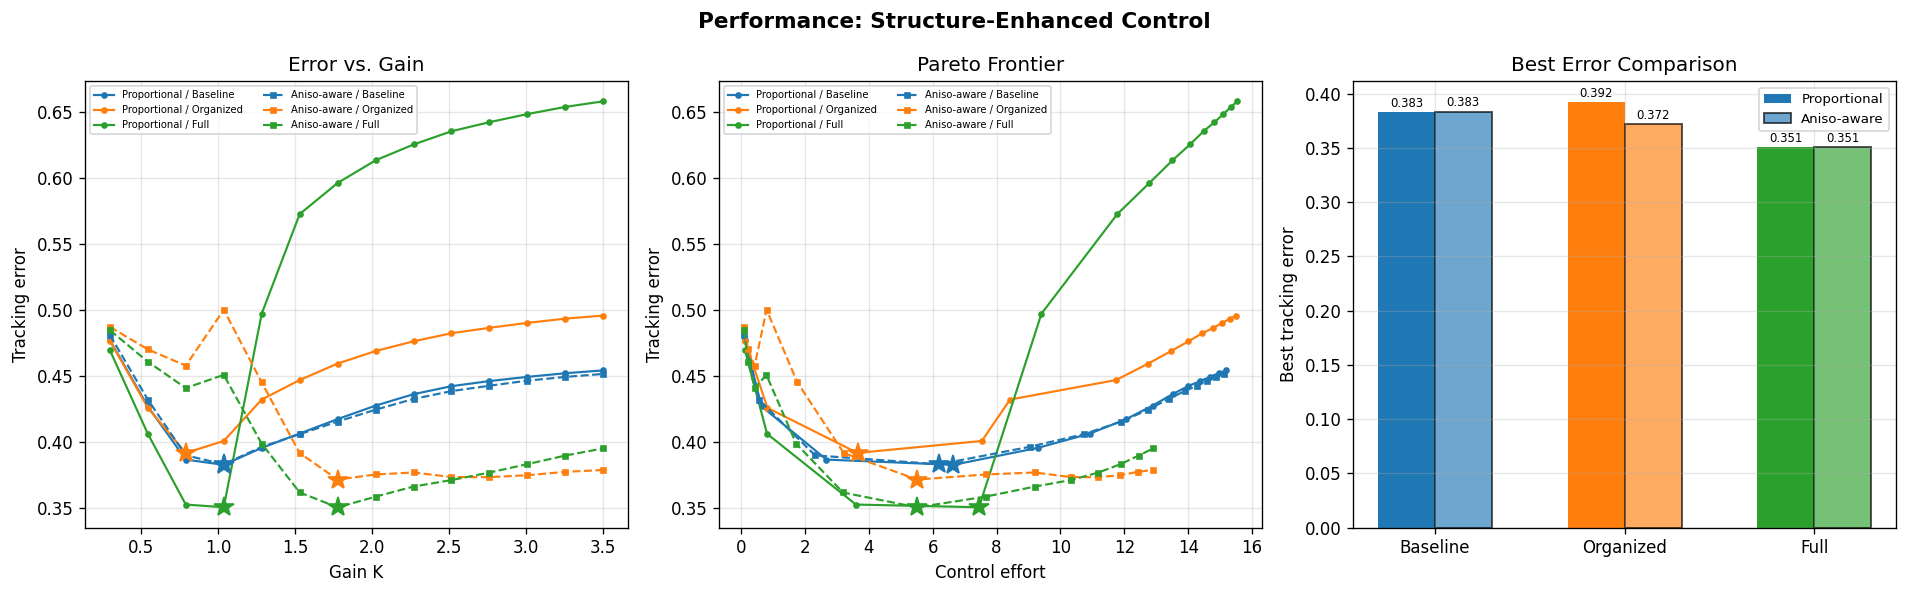


Best tracking error per (controller, regime):
Controller       Regime          Error     K*   Aniso
---------------------------------------------------
Proportional     Baseline       0.3829   1.04    1.15
Proportional     Organized      0.3919   0.79    3.16
Proportional     Full           0.3508   1.04    2.90
Aniso-aware      Baseline       0.3834   1.04    1.06
Aniso-aware      Organized      0.3718   1.78    2.78
Aniso-aware      Full           0.3507   1.78    2.78


In [5]:
K_sweep = np.linspace(0.3, 3.5, 14)
ctrl_specs = {"Proportional": make_proportional, "Aniso-aware": make_aniso_aware}
markers = {"Proportional": 'o', "Aniso-aware": 's'}
lstyles = {"Proportional": '-', "Aniso-aware": '--'}

perf = {}
print("Running performance sweep ...", end=" ", flush=True)
for cn, cm in ctrl_specs.items():
    for rn, rg in REGIMES.items():
        errs, effs, anisos = [], [], []
        for K in K_sweep:
            res = simulate(cm(K), regime=rg, seed=42)
            m = metrics(res)
            errs.append(m["error"])
            effs.append(m["effort"])
            anisos.append(m["aniso"])
        perf[(cn, rn)] = {"errors": errs, "efforts": effs, "anisos": anisos}
print("done.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for cn in ctrl_specs:
    for rn in REGIMES:
        errs = perf[(cn, rn)]["errors"]
        effs = perf[(cn, rn)]["efforts"]
        c = REG_COLORS[rn]
        ls = lstyles[cn]
        mk = markers[cn]
        label = f"{cn} / {rn}"
        axes[0].plot(K_sweep, errs, ls, color=c, marker=mk, ms=3, label=label, lw=1.3)
        axes[1].plot(effs, errs, ls, color=c, marker=mk, ms=3, label=label, lw=1.3)

        best_i = int(np.argmin(errs))
        axes[0].plot(K_sweep[best_i], errs[best_i], '*', color=c, ms=12, zorder=5)
        axes[1].plot(effs[best_i], errs[best_i], '*', color=c, ms=12, zorder=5)

# Bar chart: best error per (controller, regime)
reg_names = list(REGIMES.keys())
x_pos = np.arange(len(reg_names))
width = 0.3
for i, cn in enumerate(ctrl_specs):
    best_errs = [min(perf[(cn, rn)]["errors"]) for rn in reg_names]
    offset = (i - 0.5) * width
    bars = axes[2].bar(x_pos + offset, best_errs, width=width, label=cn,
                       color=[REG_COLORS[rn] for rn in reg_names],
                       edgecolor='black' if i == 1 else 'none', linewidth=1.2,
                       alpha=1.0 if i == 0 else 0.65)
    for bar, err in zip(bars, best_errs):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{err:.3f}', ha='center', va='bottom', fontsize=7)

axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(reg_names)
axes[2].set_ylabel("Best tracking error")
axes[2].legend(fontsize=8)
axes[2].set_title("Best Error Comparison")

axes[0].set(xlabel="Gain K", ylabel="Tracking error", title="Error vs. Gain")
axes[1].set(xlabel="Control effort", ylabel="Tracking error", title="Pareto Frontier")
for ax in axes[:2]:
    ax.legend(fontsize=6, ncol=2)

fig.suptitle("Performance: Structure-Enhanced Control",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBest tracking error per (controller, regime):")
print(f"{'Controller':<16s} {'Regime':<12s} {'Error':>8s} {'K*':>6s} {'Aniso':>7s}")
print("-" * 51)
for cn in ctrl_specs:
    for rn in REGIMES:
        errs = perf[(cn, rn)]["errors"]
        anisos = perf[(cn, rn)]["anisos"]
        best_i = int(np.argmin(errs))
        print(f"{cn:<16s} {rn:<12s} {errs[best_i]:8.4f} {K_sweep[best_i]:6.2f} "
              f"{anisos[best_i]:7.2f}")


## Summary and outlook

### Key findings

1. **Structural phase transition**: Above a critical control intensity
   ($\mathrm{tr}(G)/2 > g_c$), the Landau self-interaction drives spontaneous symmetry
   breaking in $G_{ik}$. The tensor organizes into a stable anisotropic configuration —
   visible as an eigenvalue split.

2. **Structure reshapes dynamics**: Through the $\kappa\,Q\,x$ coupling, the organized $G$
   modifies the effective plant. Directions of high $G$ gain extra damping; low-$G$
   directions become less stable. This creates a **complementary geometry**: noisy axes
   are self-stabilising, clean axes need active control.

3. **Performance sweet spot**: Moderate control creates useful structure that can improve
   tracking. Excessive control inflates $\mathrm{tr}(G)$, overwhelming observations with
   noise. The optimal gain sits near the phase transition boundary.

4. **Structure-aware control**: The aniso-aware controller, which focuses effort along
   low-$G$ axes, naturally exploits the complementary geometry of the organized state.

### Connections

- **Plasma analogy**: $G_{ik}$ anisotropy $\leftrightarrow$ ExB shear barrier;
  phase transition $\leftrightarrow$ L$\to$H mode; $\kappa\,Q\,x$ coupling
  $\leftrightarrow$ barrier-enhanced confinement ($\tau_E$)
- **Scalar limit**: When $G = g\cdot I$, the self-interaction vanishes ($Q = 0$) and the
  model reduces to the resolution degradation model in `control.ipynb`
- **Fundamental scale**: At $\ell \approx \mathrm{tr}(G)/2 \to \ell_*$, quantum effects
  should modify the self-interaction (future work)

### Next steps

- Pulsed control strategies that maintain structure while managing $\mathrm{tr}(G)$
- Multiple competing structural modes (higher-dimensional $G$)
- Coupling to the plasma confinement model (`plasma_pulse_opt`)